In [1]:
import sys
sys.path.append('../') 
from src.olah_data import load_and_preprocess

# Memuat data yang sudah bersih dan memiliki fitur tambahan (Risk_Level)
df = load_and_preprocess()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Risk_Level
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,Low
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,Low
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,High
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,High
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,High


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         302 non-null    int64  
 1   sex         302 non-null    int64  
 2   cp          302 non-null    int64  
 3   trestbps    302 non-null    int64  
 4   chol        302 non-null    int64  
 5   fbs         302 non-null    int64  
 6   restecg     302 non-null    int64  
 7   thalach     302 non-null    int64  
 8   exang       302 non-null    int64  
 9   oldpeak     302 non-null    float64
 10  slope       302 non-null    int64  
 11  ca          302 non-null    int64  
 12  thal        302 non-null    int64  
 13  target      302 non-null    int64  
 14  Risk_Level  302 non-null    object 
dtypes: float64(1), int64(13), object(1)
memory usage: 37.8+ KB


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


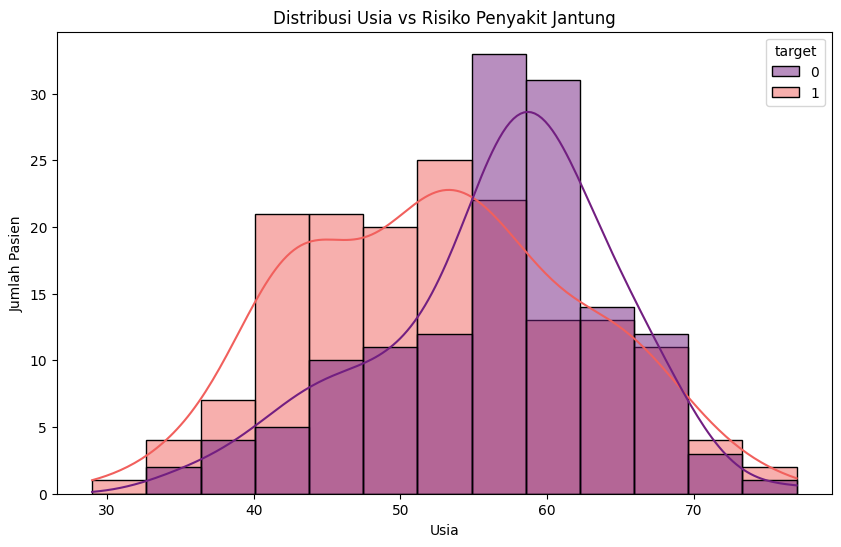

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', kde=True, palette='magma')
plt.title('Distribusi Usia vs Risiko Penyakit Jantung')
plt.xlabel('Usia')
plt.ylabel('Jumlah Pasien')
plt.show()

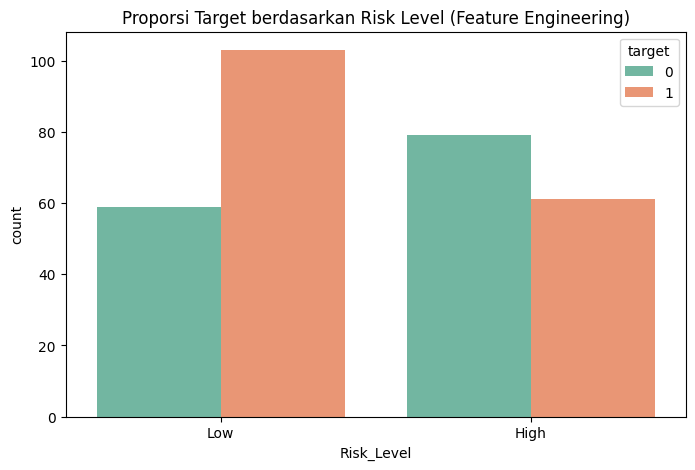

In [5]:
# Visualisasi tambahan untuk melihat hasil Feature Engineering
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Risk_Level', hue='target', palette='Set2')
plt.title('Proporsi Target berdasarkan Risk Level (Feature Engineering)')
plt.show()

--- EVALUASI MODEL PREDIKSI ---
Tingkat Akurasi Model: 83.61%

Laporan Klasifikasi Lengkap:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



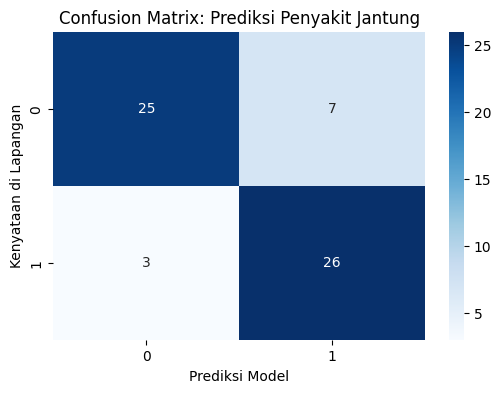

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. PREPARASI DATA (DATA PREPARATION)
# Kita akan memprediksi kolom 'target' (1 = sakit, 0 = sehat).
# Kita hapus kolom 'target' dari fitur (X) dan hapus 'Risk_Level' karena itu buatan kita sendiri.
X = df.drop(['target', 'Risk_Level'], axis=1)
y = df['target']

# 2. SPLITTING DATA
# Membagi data: 80% untuk melatih model, 20% untuk menguji keakuratan model.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. MEMBANGUN MODEL (RANDOM FOREST)
# Menggunakan Random Forest karena algoritma ini sangat tangguh untuk data medis.
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. EVALUASI MODEL
y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"--- EVALUASI MODEL PREDIKSI ---")
print(f"Tingkat Akurasi Model: {akurasi * 100:.2f}%")
print("\nLaporan Klasifikasi Lengkap:")
print(classification_report(y_test, y_pred))

# 5. VISUALISASI CONFUSION MATRIX
# Ini untuk menunjukkan seberapa banyak model salah tebak (False Positive/Negative)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Prediksi Penyakit Jantung')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan di Lapangan')
plt.show()

In [7]:
from sqlalchemy import create_engine

# 1. Konfigurasi (Ganti password sesuai milikmu)
user = 'postgres'
password = 'Masuk123*' 
host = 'localhost'
port = '5432'
db_name = 'db_health'

# 2. Hubungkan dan Kirim
try:
    engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{db_name}')
    
    # Kita simpan dengan nama tabel yang sangat profesional
    df.to_sql('fact_heart_disease_final', engine, if_exists='replace', index=False)
    
    print("--- PIPELINE SELESAI ---")
    print("1. Data Cleaning: SUKSES")
    print("2. Feature Engineering (Risk Level): SUKSES")
    print("3. Machine Learning Integration: SUKSES")
    print("4. Data Warehouse Loading (PostgreSQL): SUKSES")
    print("\nSekarang buka Power BI dan tarik tabel 'fact_heart_disease_final'")
except Exception as e:
    print(f"Gagal mengirim data: {e}")

--- PIPELINE SELESAI ---
1. Data Cleaning: SUKSES
2. Feature Engineering (Risk Level): SUKSES
3. Machine Learning Integration: SUKSES
4. Data Warehouse Loading (PostgreSQL): SUKSES

Sekarang buka Power BI dan tarik tabel 'fact_heart_disease_final'
